In [1]:
import pandas as pd
import numpy as np

# llama-3.3-70B.csv
MODEL_IDS = ["qwen-3.5-27B", "llama-3.3-70B", "gemma-4-31B", "gpt-5.5"]
MEASURES = [("humt", "Human Likeness"), ("sociot_status", "Status"), ("sociot_social_distance", "Social Distance"), ("sociot_gender", "Gender"), ("sociot_warmth", "Warmth")]

In [ ]:
# merge results
dfs = [pd.read_csv("/mnt/homes/marlene/SEAL/seal/results/sampled_dataset_responses_clean.csv", index_col="id")]
for model_id in MODEL_IDS:
    print(model_id)
    # /mnt/homes/marlene/SEAL/seal/evaluation/human_likeness/humtdumt/results/sampled_dataset_responses_clean_responses_gemma-4-31B.csv
    path = f"/mnt/homes/marlene/SEAL/seal/evaluation/human_likeness/humtdumt/results/sampled_dataset_responses_clean_responses_{model_id}.csv"
    df = pd.read_csv(path, index_col="id")
    dfs.append(df)

merged = pd.concat(dfs, axis=1, join="outer")
merged = merged.loc[:, ~merged.columns.duplicated()]

merged = merged.drop(columns=["Unnamed: 0", "Unnamed: 13"])
merged.info()
merged.to_csv("human_likeness_all_models.csv", index="id")


qwen-3.5-27B
llama-3.3-70B
gemma-4-31B
gpt-5.5
<class 'pandas.core.frame.DataFrame'>
Index: 2691 entries, u487p5 to u453p1
Data columns (total 90 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   prompt                                              2691 non-null   object 
 1   ses                                                 2691 non-null   int64  
 2   social_class                                        2691 non-null   object 
 3   gender                                              2691 non-null   object 
 4   gender_other                                        30 non-null     object 
 5   age                                                 2691 non-null   object 
 6   nationality                                         2669 non-null   object 
 7   ethnicity                                           2663 non-null   object 
 8   ethnicity_other              

In [4]:
# keep only important columns
merged_clean = merged.loc[:, ~merged.columns.str.startswith("std") & ~merged.columns.str.endswith("trunc")]
merged_clean.to_csv("human_likeness_all_models_clean.csv", index="id")

merged_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2691 entries, u487p5 to u453p1
Data columns (total 66 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   prompt                                          2691 non-null   object 
 1   ses                                             2691 non-null   int64  
 2   social_class                                    2691 non-null   object 
 3   gender                                          2691 non-null   object 
 4   gender_other                                    30 non-null     object 
 5   age                                             2691 non-null   object 
 6   nationality                                     2669 non-null   object 
 7   ethnicity                                       2663 non-null   object 
 8   ethnicity_other                                 54 non-null     object 
 9   marital                                

In [5]:
# collect results for plotting
res = {} 

for model_id in MODEL_IDS: 
    path = f"/mnt/homes/marlene/SEAL/seal/evaluation/human_likeness/humtdumt/results/sampled_dataset_responses_clean_responses_{model_id}.csv"
    res[model_id] = pd.read_csv(path, index_col="id")

res

{'qwen-3.5-27B':         Unnamed: 0                                             prompt  ses  \
 id                                                                           
 u487p5           0  How to customize the link color using CSS for ...    7   
 u825p5           1  Can you help me come up with some blog post id...    8   
 u795p3           2                          books for finding meaning    3   
 u709p1           3                        The best beer for SuperBowl    3   
 u282p2           4       who was the greatest scientist to ever live?    5   
 ...            ...                                                ...  ...   
 u180p6        2686  How did Canada respond to Donald Trump’s threa...    5   
 u361p9        2687    very interesting, keep going and generate more.    4   
 u222p4        2688   if a guy stares at me does that mean he likes me    4   
 u487p2        2689      When does Arizona start accepting tax returns    7   
 u453p1        2690  Please provide 

In [6]:

# print mean per ses category

for model_id, df in res.items():
    print(model_id)

    # Print means for each social class
    for measure,_ in MEASURES:
        print(f"\n{measure}")
        col = f"{measure}_responses_{model_id}" # sociot_status_responses_gemma-4-31B
        print(df.groupby("social_class", observed=True)[col].mean().round(3))

    print()

qwen-3.5-27B

humt
social_class
low       0.017
middle    0.014
upper     0.014
Name: humt_responses_qwen-3.5-27B, dtype: float64

sociot_status
social_class
low      -0.052
middle   -0.052
upper    -0.051
Name: sociot_status_responses_qwen-3.5-27B, dtype: float64

sociot_social_distance
social_class
low       0.036
middle    0.036
upper     0.035
Name: sociot_social_distance_responses_qwen-3.5-27B, dtype: float64

sociot_gender
social_class
low       0.004
middle    0.004
upper     0.001
Name: sociot_gender_responses_qwen-3.5-27B, dtype: float64

sociot_warmth
social_class
low       0.016
middle    0.014
upper     0.015
Name: sociot_warmth_responses_qwen-3.5-27B, dtype: float64

llama-3.3-70B

humt
social_class
low       0.019
middle    0.020
upper     0.015
Name: humt_responses_llama-3.3-70B, dtype: float64

sociot_status
social_class
low      -0.056
middle   -0.056
upper    -0.056
Name: sociot_status_responses_llama-3.3-70B, dtype: float64

sociot_social_distance
social_class
low   

### Mean and 95% Confidence Interval

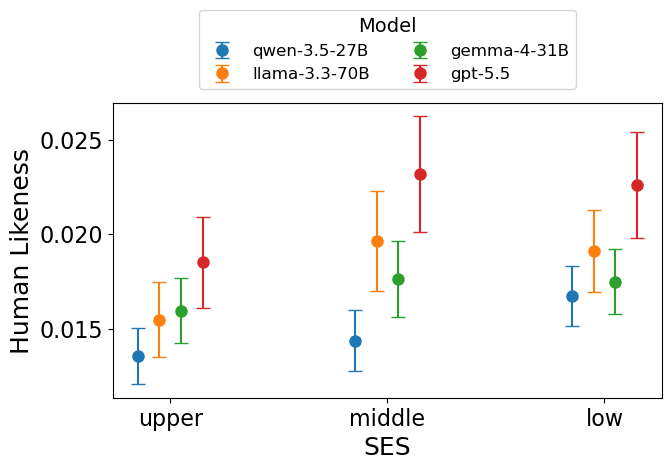

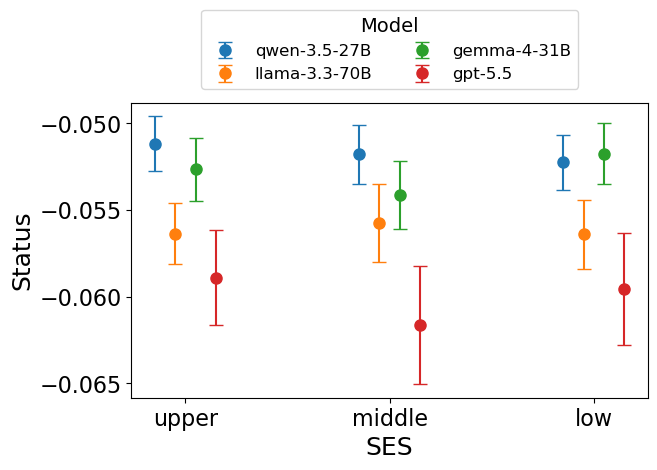

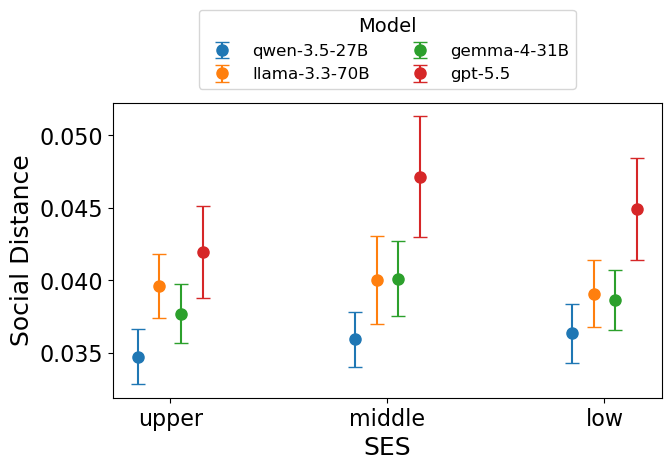

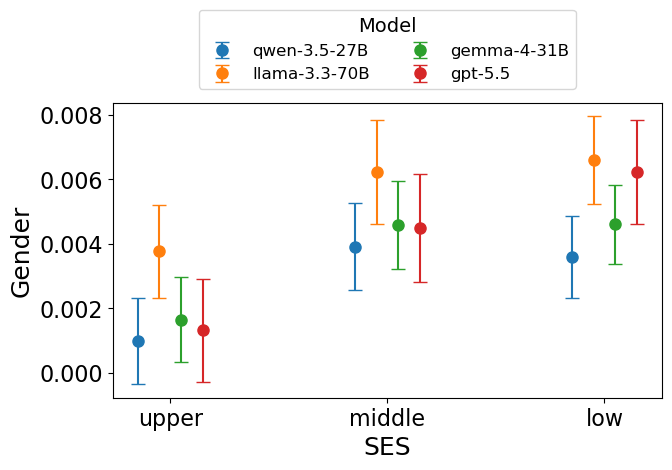

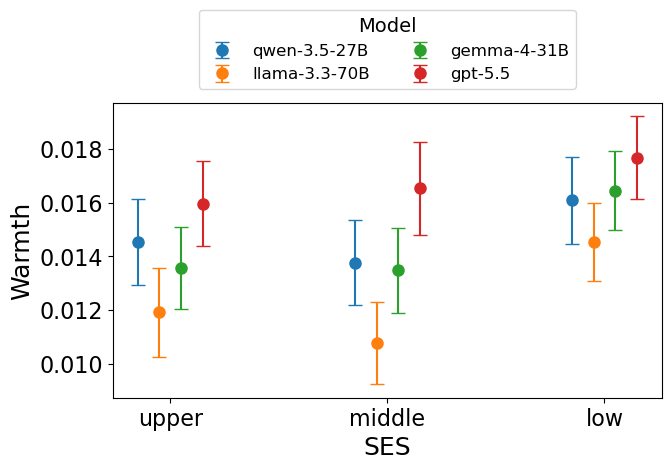

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 12,
    "legend.title_fontsize": 14
})

    
ses_order = ["upper", "middle", "low"]

for measure, m_name in MEASURES:

    plot_data = []

    for model_id, df in res.items():

        df = df.copy()
        col = f"{measure}_responses_{model_id}"

        stats = (
            df.groupby("social_class", observed=True)[col]
            .agg(["mean", "std", "count"])
            .reindex(ses_order)
        )

        stats["ci95"] = (
            1.96 * stats["std"] / np.sqrt(stats["count"])
        )

        for ses, row in stats.iterrows():
            plot_data.append({
                "model": model_id,
                "social_class": ses,
                "mean": row["mean"],
                "ci95": row["ci95"]
            })

    plot_df = pd.DataFrame(plot_data)

    models = plot_df["model"].unique()

    fig, ax = plt.subplots(figsize=(7, 5))

    x = np.arange(len(ses_order))
    dodge_width = 0.4 / len(models)

    for i, model in enumerate(models):

        model_df = plot_df[plot_df["model"] == model]

        xpos = (
            x 
            + (i - len(models) / 2) * dodge_width 
            + dodge_width / 2
        )

        values = [
            model_df.loc[
                model_df["social_class"] == ses, "mean"
            ].values[0]
            for ses in ses_order
        ]

        errors = [
            model_df.loc[
                model_df["social_class"] == ses, "ci95"
            ].values[0]
            for ses in ses_order
        ]

        ax.errorbar(
            xpos,
            values,
            yerr=errors,
            fmt="o",
            markersize=8,
            capsize=5,
            label=model
        )

    ax.set_xticks(x)
    ax.set_xticklabels(ses_order)

    ax.set_xlabel("SES")
    ax.set_ylabel(m_name)

    ax.legend(
        title="Model",
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=2,
    )

    plt.tight_layout()
    plt.show()

### Violin Plots to check the score distribution

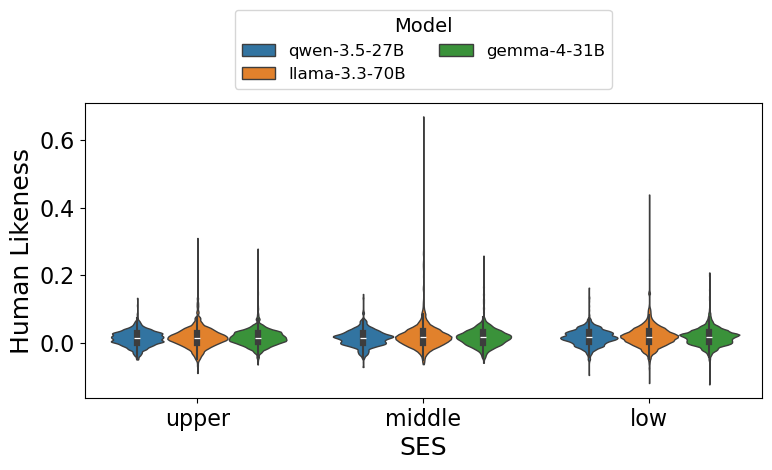

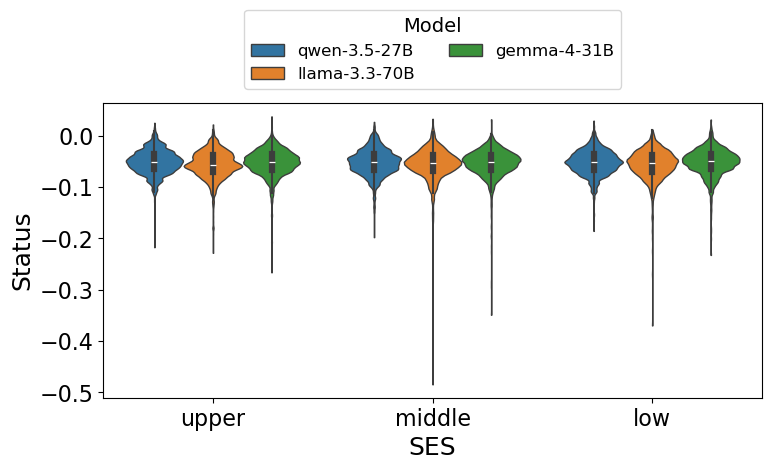

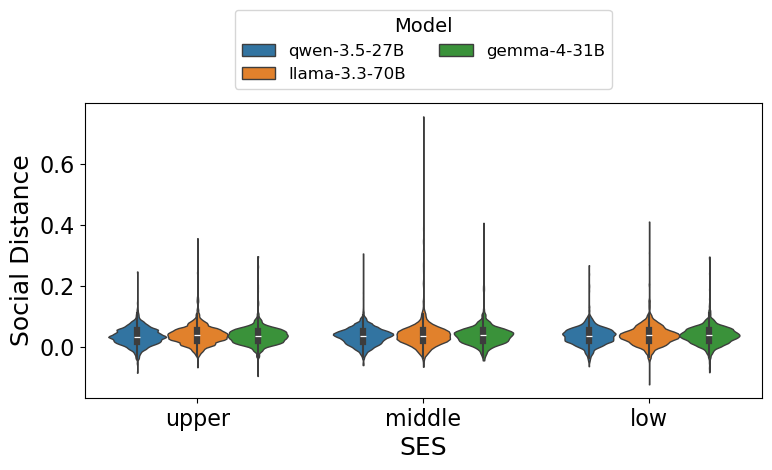

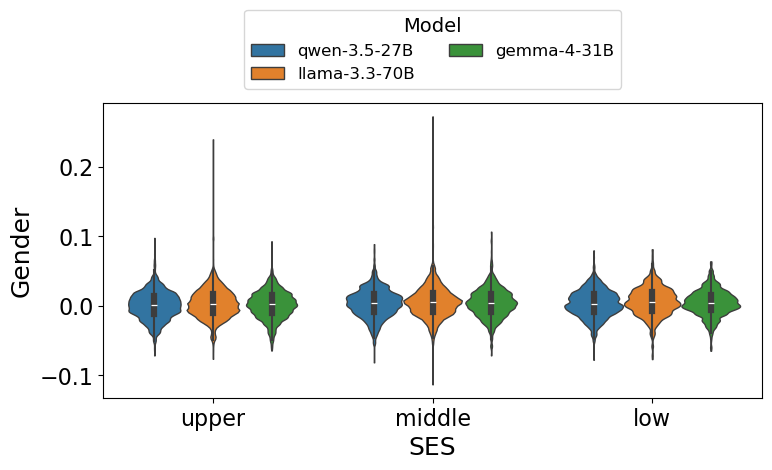

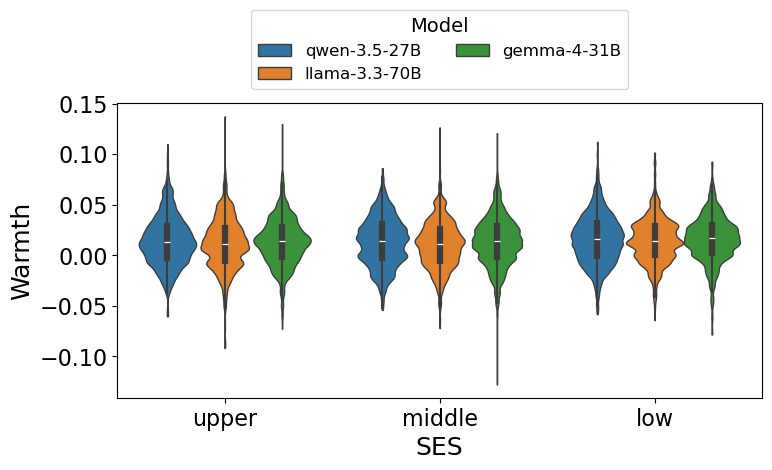

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np


ses_order = ["upper", "middle", "low"]

for measure, m_name in MEASURES:

    plot_data = []

    for model_id, df in res.items():

        df = df.copy()
        col = f"{measure}_responses_{model_id}"

        temp = df[["social_class", col]].copy()
        temp = temp.rename(columns={col: "score"})

        temp["model"] = model_id
        temp["social_class"] = pd.Categorical(
            temp["social_class"],
            categories=ses_order,
            ordered=True
        )

        plot_data.append(temp)

    plot_df = pd.concat(plot_data, ignore_index=True)

    fig, ax = plt.subplots(figsize=(8, 5))

    sns.violinplot(
        data=plot_df,
        x="social_class",
        y="score",
        hue="model",
        order=ses_order,
        dodge=True,
        cut=0,
        inner="box",
        bw_adjust=0.5,
        linewidth=1,
        ax=ax
    )

    ax.set_xlabel("SES")
    ax.set_ylabel(m_name)

    ax.legend(
        title="Model",
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=2
    )

    plt.tight_layout()
    plt.show()

### Data for qualitative analysis

In [16]:
df_gpt = pd.read_csv("humtdumt/results/sampled_dataset_responses_clean_responses_gpt-5.5.csv", index_col="id")

#df_gpt.info()

df_human_likeness = df_gpt[["prompt", "social_class", "responses_gpt-5.5", "responses_gpt-5.5_trunc", "humt_responses_gpt-5.5"]]
df_warmth = df_gpt[["prompt", "social_class", "responses_gpt-5.5", "responses_gpt-5.5_trunc", "sociot_warmth_responses_gpt-5.5"]]

df_human_likeness.to_csv("gpt-5.5_huamn_likeness.csv", index="id")
df_warmth.to_csv("gpt-5.5_warmth.csv", index="id")